In [3]:
import requests
from datetime import datetime, timedelta

API_KEY = "b2a0d07341544104b699c5576a1bf7fd"
url = "https://newsapi.org/v2/everything"

# Query parameters
query = "finance AND (stock market OR investment)"
language = "en"
page_size = 100  # max per request

# Date range setup: last 30 days
end_date = datetime.today()
start_date = end_date - timedelta(days=30)

all_articles = []

# Split the 30-day range into 3-day chunks (adjust as needed)
delta = timedelta(days=3)
current_start = start_date

while current_start < end_date:
    current_end = min(current_start + delta, end_date)
    
    page = 1
    while True:
        params = {
            "q": query,
            "language": language,
            "pageSize": page_size,
            "page": page,
            "from": current_start.strftime("%Y-%m-%d"),
            "to": current_end.strftime("%Y-%m-%d"),
            "apiKey": API_KEY
        }

        response = requests.get(url, params=params)
        data = response.json()

        if "articles" in data and data["articles"]:
            all_articles.extend(data["articles"])
            if len(data["articles"]) < page_size:
                break  # No more pages for this date range
            page += 1
        else:
            break  # No articles for this page/date range

    current_start += delta

# Extract text
news_list = []
for article in all_articles:
    text = article.get("title", "") + " " + str(article.get("description", ""))
    news_list.append(text)

print(f"Total articles fetched: {len(news_list)}")
print(news_list[:10])

Total articles fetched: 870
['The private credit market has a growing AI problem AI-driven disruption, particularly in sectors like software, is increasingly being flagged as a risk.', 'Bank of America resets Nvidia price target after earnings Nvidia (NVDA) reported its Q4 earnings on Feb. 25 after the bell. Despite the earnings smasher, the stock is trading 5.6% lower at the time of writing...', "Late Rolling Stones Drummer Charlie Watts 8,500-Square-Foot English Manor Lists for $3.7M Rolling Stones drummer Charlie Watts' English country manor is up for sale for £2.7 million ($3.7 million). Watts, who died in 2021, purchased the property...", "Bitcoin Critic David Stockman Gets Reality Check After Popular Analyst Likens BTC Slump To Drawdowns In 'Trillion Dollar Stocks' Like Nvidia, Amazon Cryptocurrency analyst Willy Woo countered former White House official David Stockman‘s critique of Bitcoin’s (CRYPTO: BTC) “store of value” narrative on...", 'Warner Bros. earnings, Fed, jobless cl

In [5]:
candidate_labels = [
    "credible financial news",
    "misleading or exaggerated",
    "opinion or speculation",
    "clickbait"
]

In [7]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


C:\Users\Felicia\AppData\Roaming\Python\Python311\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [9]:
misinfo_results = []

for article in news_list[:15]:
    result = classifier(article, candidate_labels)

    misinfo_results.append({
        "text": article,
        "label": result['labels'][0],
        "score": result['scores'][0]
    })

In [ ]:
misinfo_results = []

for i in range(0, len(news_list), batch_size):
    batch = news_list[i:i+batch_size]
    
    results = classifier(batch, candidate_labels)

    for r, text in zip(results, batch):
        misinfo_results.append({
            "text

In [11]:
from collections import Counter

labels = [r['label'] for r in misinfo_results]
counts = Counter(labels)

print(counts)

Counter({'credible financial news': 9, 'opinion or speculation': 5, 'misleading or exaggerated': 1})


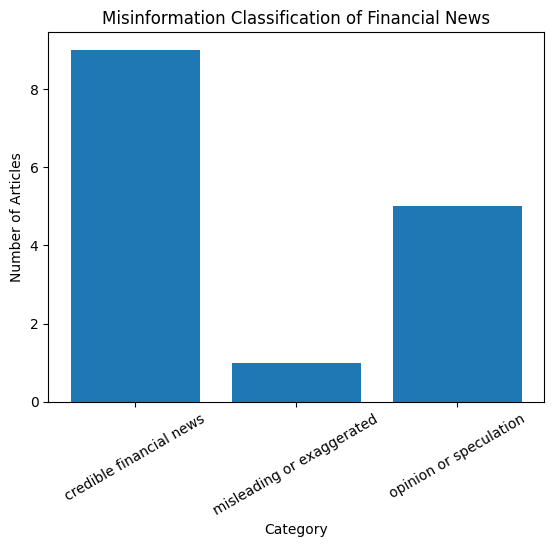

In [13]:
import matplotlib.pyplot as plt

plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=30)
plt.title("Misinformation Classification of Financial News")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()